In [1]:
import pandas as pd 
import os 
from sklearn.metrics import (roc_auc_score ,roc_curve)
df = pd.read_parquet(r"D:\fraud_detection_using_ML\data\raw\ieee_fraud_detection.parquet", engine= "pyarrow")

In [2]:
df.shape

(590528, 202)

In [3]:
df.head()


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,135.0,0.0,0.0,0.0,50.0,1404.0,790.0,0.0,0.0,0.0
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
df.sample(10)

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321
11403,2998403,0,336812,50.000000,H,3475,555.0,150.0,None,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
327421,3314422,0,8046855,117.000000,W,17188,321.0,150.0,visa,226.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
125826,3112827,0,2492996,39.936001,C,9633,296.0,185.0,visa,138.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
485003,3472009,0,12617698,108.949997,W,9267,321.0,150.0,visa,226.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
320018,3307019,0,7950219,117.000000,W,7482,490.0,150.0,visa,226.0,...,280.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
455849,3442850,0,11654907,884.000000,W,13220,562.0,150.0,mastercard,197.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,554.0,0.0
16906,3003906,0,443370,50.000000,H,5147,555.0,150.0,mastercard,117.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
322366,3309367,0,8009699,54.500000,W,8394,490.0,150.0,visa,226.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
117939,3104940,0,2307713,29.000000,W,1333,170.0,150.0,visa,195.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
260081,3247082,0,6227569,226.000000,W,15398,235.0,150.0,mastercard,224.0,...,226.0,0.0,0.0,0.0,0.0,950.0,950.0,0.0,0.0,0.0


In [5]:
fraud_df = df[df["isFraud"] == 1]

fraud_df

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321
203,2987203,1,89760,445.000000,W,18268,583.0,150.0,visa,226.0,...,0.0,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,0.0,0.0
240,2987240,1,90193,37.098000,C,13413,103.0,185.0,visa,137.0,...,0.0,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,0.0,0.0
243,2987243,1,90246,37.098000,C,13413,103.0,185.0,visa,137.0,...,0.0,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,0.0,0.0
245,2987245,1,90295,37.098000,C,13413,103.0,185.0,visa,137.0,...,0.0,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,0.0,0.0
288,2987288,1,90986,155.520996,C,16578,545.0,185.0,visa,226.0,...,0.0,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590349,3577361,1,15807368,1224.000000,W,3278,453.0,150.0,visa,226.0,...,0.0,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,0.0,0.0
590352,3577364,1,15807516,69.963997,C,5812,408.0,185.0,mastercard,224.0,...,0.0,0.0,0.0,0.0,0.0,48.0774,0.0,0.0,0.0,0.0
590356,3577368,1,15807677,100.000000,H,6758,399.0,150.0,american express,146.0,...,0.0,NaN,NaN,NaN,0.0,0.0000,0.0,0.0,0.0,0.0
590360,3577372,1,15807758,117.000000,W,14037,111.0,150.0,visa,226.0,...,0.0,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,0.0,0.0


In [6]:
df["isFraud"].value_counts()

isFraud
0    569865
1     20663
Name: count, dtype: int64

In [7]:
# Set the TransactionID to index
df.set_index('TransactionID', inplace=True)

In [8]:
df.head()

,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,...,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321
TransactionID,,,,,,,,,,,,,,,,,,,,,
2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,...,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0
2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,...,135.0,0.0,0.0,0.0,50.0,1404.0,790.0,0.0,0.0,0.0
2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 590528 entries, 2987000 to 3577539
Columns: 201 entries, isFraud to V321
dtypes: float32(193), int32(3), object(5)
memory usage: 466.3+ MB


In [10]:
df.dtypes

isFraud             int32
TransactionDT       int32
TransactionAmt    float32
ProductCD          object
card1               int32
                   ...   
V317              float32
V318              float32
V319              float32
V320              float32
V321              float32
Length: 201, dtype: object

In [11]:
df.dtypes.value_counts()


float32    193
object       5
int32        3
Name: count, dtype: int64

### Data Cleaning and Preprocessing 

In [12]:
def check_missing(df, dtype='object'):
    # Total number of rows
    total_rows = df.shape[0]

    # Check missing values and their percentage for specified dtype
    missing_ = df.select_dtypes(include=dtype).isnull().sum()
    missing_percent = (missing_ / total_rows) * 100

    # Combine into a DataFrame for better readability
    missing_summary = pd.DataFrame({
        'Missing Values': missing_,
        'Missing Percentage (%)': missing_percent.round(2)
    })

    # Filter out columns without missing values
    missing_summary = missing_summary[missing_summary['Missing Values'] > 0]

    # Sort by missing percentage
    return missing_summary.sort_values(by='Missing Percentage (%)', ascending=False)

In [13]:
# For numeric types
check_missing(df, dtype=['float32', 'int32'])

,Missing Values,Missing Percentage (%)
V52,168957,28.61
V51,168957,28.61
V37,168957,28.61
V38,168957,28.61
V39,168957,28.61
...,...,...
V317,11,0.00
V318,11,0.00
V319,11,0.00
V320,11,0.00


In [14]:
# For categorical
check_missing(df, dtype='object')

,Missing Values,Missing Percentage (%)
M6,169348,28.68
P_emaildomain,94454,15.99
card6,1571,0.27
card4,1577,0.27


### Handle missing values 

In [15]:
# Fill numeric columns with median
num_cols = df.select_dtypes(include=['number']).columns
for col in num_cols:
  median = df[col].median()
  df.fillna({col:median}, inplace=True)

In [16]:
# Fill categorical columns with most frequent value (mode)
cat_cols = df.select_dtypes(include=['object', 'category']).columns
for col in cat_cols:
  mode = df[col].mode(dropna=True)
  if not mode.empty:
    df.fillna({col:mode[0]}, inplace=True)

In [17]:
df.head(20)

,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,...,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321
TransactionID,,,,,,,,,,,,,,,,,,,,,
2987000,0,86400,68.500000,W,13926,361.0,150.0,discover,142.0,credit,...,0.000000,0.000000,0.000000,0.000000,0.0,117.0,0.0,0.000000,0.000000,0.000000
2987001,0,86401,29.000000,W,2755,404.0,150.0,mastercard,102.0,credit,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
2987002,0,86469,59.000000,W,4663,490.0,150.0,visa,166.0,debit,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
2987003,0,86499,50.000000,W,18132,567.0,150.0,mastercard,117.0,debit,...,135.000000,0.000000,0.000000,0.000000,50.0,1404.0,790.0,0.000000,0.000000,0.000000
2987004,0,86506,50.000000,H,4497,514.0,150.0,mastercard,102.0,credit,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
2987005,0,86510,49.000000,W,5937,555.0,150.0,visa,226.0,debit,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
2987006,0,86522,159.000000,W,12308,360.0,150.0,visa,166.0,debit,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
2987007,0,86529,422.500000,W,12695,490.0,150.0,visa,226.0,debit,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
2987008,0,86535,15.000000,H,2803,100.0,150.0,visa,226.0,debit,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000


In [18]:
df.isnull().sum()

isFraud           0
TransactionDT     0
TransactionAmt    0
ProductCD         0
card1             0
                 ..
V317              0
V318              0
V319              0
V320              0
V321              0
Length: 201, dtype: int64

### Identify Highly correlated numeric variables

In [19]:
# Compute the correlation matrix (for numerical columns only)
corr_matrix = df.select_dtypes(include=['number']).corr()

In [20]:
import numpy as np

def get_high_correlations(corr_matrix, threshold=0.9):
	# Take the upper triangle of the correlation matrix without the diagonal
	upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

	# Find features with correlation greater than the threshold
	high_corr = [(col, row, upper.loc[row, col])
	for col in upper.columns
	for row in upper.index
	if abs(upper.loc[row, col]) > threshold]

	return sorted(high_corr, key=lambda x: -abs(x[2]))

In [21]:
# Then call it
high_corr_pairs = get_high_correlations(corr_matrix, threshold=0.9)
for feature1, feature2, corr_value in high_corr_pairs[:10]:
  print(f"{feature1} ↔ {feature2} = {corr_value:.2f}")

V101 ↔ V95 = 1.00
V293 ↔ V279 = 1.00
C12 ↔ C7 = 1.00
V293 ↔ V101 = 1.00
V103 ↔ V97 = 1.00
V279 ↔ V95 = 1.00
V295 ↔ V280 = 1.00
V293 ↔ V95 = 1.00
V279 ↔ V101 = 1.00
V316 ↔ V132 = 1.00


### Dropping redundant columns 

In [22]:

to_drop = set()
for feature1, feature2, _ in high_corr_pairs:
	if feature1 not in to_drop:
	  to_drop.add(feature2)

df.drop(columns=list(to_drop), inplace=True)

### Encoding of categorical columns

In [23]:
# Select categorical columns
cat_cols = df.select_dtypes(include='object').columns

# Count unique values in each categorical column
cardinality = df[cat_cols].nunique().sort_values(ascending=False)


In [24]:
from sklearn.preprocessing import LabelEncoder

# Label Encoding for high-cardinality feature
le = LabelEncoder()
df['P_emaildomain'] = le.fit_transform(df['P_emaildomain'])

# One-Hot Encoding for low-cardinality features
df = pd.get_dummies(df, columns=['ProductCD', 'card4', 'card6', 'M6'], drop_first=True)

In [25]:
df.head()

,isFraud,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,P_emaildomain,...,ProductCD_R,ProductCD_S,ProductCD_W,card4_discover,card4_mastercard,card4_visa,card6_credit,card6_debit,card6_debit or credit,M6_T
TransactionID,,,,,,,,,,,,,,,,,,,,,
2987000,0,86400,68.5,13926,361.0,150.0,142.0,315.0,87.0,16,...,False,False,True,True,False,False,True,False,False,True
2987001,0,86401,29.0,2755,404.0,150.0,102.0,325.0,87.0,16,...,False,False,True,False,True,False,True,False,False,True
2987002,0,86469,59.0,4663,490.0,150.0,166.0,330.0,87.0,35,...,False,False,True,False,False,True,False,True,False,False
2987003,0,86499,50.0,18132,567.0,150.0,117.0,476.0,87.0,53,...,False,False,True,False,True,False,False,True,False,False
2987004,0,86506,50.0,4497,514.0,150.0,102.0,420.0,87.0,16,...,False,False,False,False,True,False,True,False,False,False


### check imbalance 

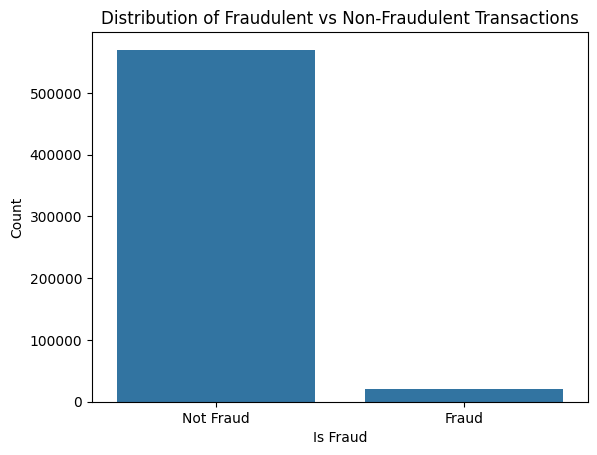

isFraud
0    96.500928
1     3.499072
Name: proportion, dtype: float64


In [26]:
# Visualize class imbalance
import seaborn as sns
import matplotlib.pyplot as plt

# Plot the class distribution
sns.countplot(x='isFraud', data=df)
plt.title('Distribution of Fraudulent vs Non-Fraudulent Transactions')
plt.xlabel('Is Fraud')
plt.ylabel('Count')
plt.xticks([0, 1], ['Not Fraud', 'Fraud'])
plt.show()

# Print percentage distribution
fraud_rate = df['isFraud'].value_counts(normalize=True) * 100
print(fraud_rate)

### Model training and evaluation 

In [27]:
# Separate features and target
X = df.drop(columns=['isFraud'])
y = df['isFraud']

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)

In [29]:
! pip install imblearn xgboost



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### USing Xgboost Algorithm 

In [77]:
# Import Required Libraries
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier

In [94]:
fraud_count = y_train.value_counts()
raw_scale = fraud_count[0] / fraud_count[1]
scale_pos_weight = raw_scale** (1/2)

classifier = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    min_child_weight=3,      # lowered from 10 — was too restrictive
    subsample=0.8,
    colsample_bytree=0.7,
    gamma=0.1,               # lowered from 1 — was pruning too aggressively
    reg_alpha=0.1,           # L1 regularization
    reg_lambda=1.0,          # L2 regularization
    random_state=42,
    eval_metric='aucpr',
    
)

In [95]:
# Create pipeline
from imblearn.combine import SMOTETomek
pipeline = ImbPipeline(steps=[
    ## ('scaler', StandardScaler()),
    ## ('sampling', SMOTETomek(random_state=42)),
    
    ('classifier', classifier)
])

In [96]:
# Perform cross-validation on training data only
from sklearn.model_selection import cross_val_score
print("Performing 5-fold cross-validation...")
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='roc_auc')
print(f"Cross-validation ROC-AUC scores: {cv_scores}")
print(f"Mean CV ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print("-" * 50)


Performing 5-fold cross-validation...
Cross-validation ROC-AUC scores: [0.936482   0.93657958 0.93970142 0.93444918 0.9388903 ]
Mean CV ROC-AUC: 0.9372 (+/- 0.0019)
--------------------------------------------------


In [97]:
pipeline.fit(X_train, y_train)

,steps,"[('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.7


Optimal threshold: 0.200


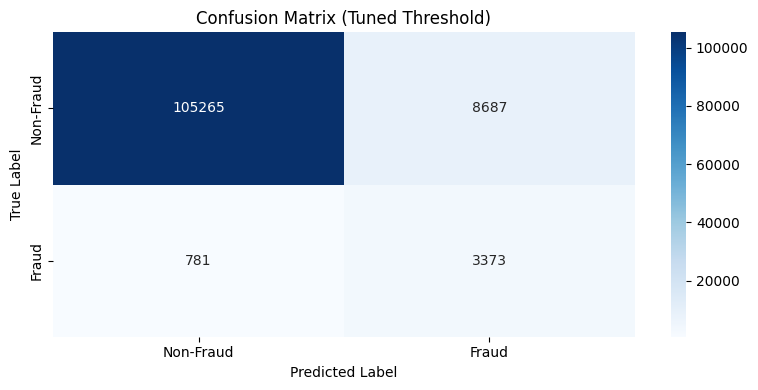


Optimal Threshold: 0.200

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.92      0.96    113952
           1       0.28      0.81      0.42      4154

    accuracy                           0.92    118106
   macro avg       0.64      0.87      0.69    118106
weighted avg       0.97      0.92      0.94    118106

ROC AUC Score: 0.9425622827684281


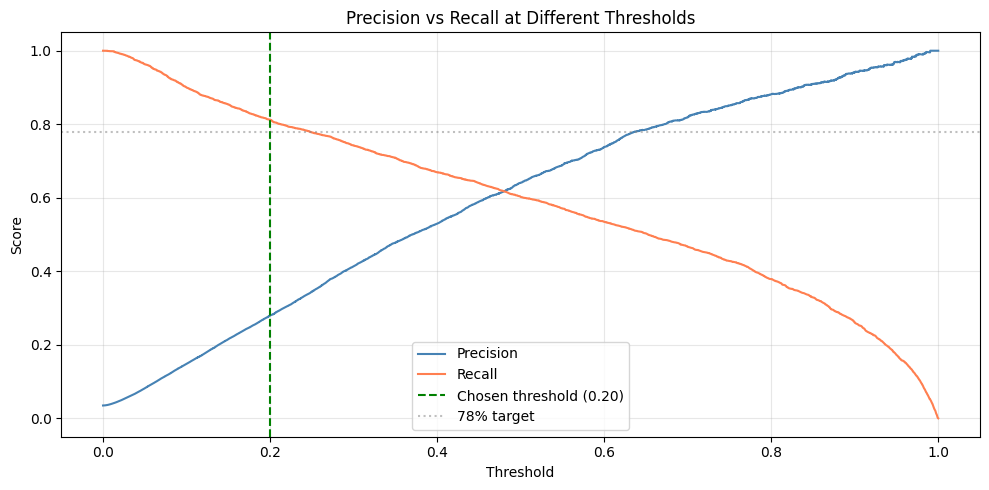

In [98]:
# Step 3: Find optimal threshold targeting ~77-80% on both metrics
from sklearn.metrics import precision_recall_curve

y_proba = pipeline.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

# Find threshold where both precision AND recall are closest to 0.78
best_threshold = 0.2
best_score = -1

for p, r, t in zip(precision[:-1], recall[:-1], thresholds):
    if p >= 0.80 and r >= 0.80:          # both must be above 70%
        harmonic = 2 * p * r / (p + r)  # F1 to pick the best balanced point
        if harmonic > best_score:
            best_score = harmonic
            best_threshold = t

print(f"Optimal threshold: {best_threshold:.3f}")

# Step 4: Apply optimal threshold
y_pred_tuned = (y_proba >= best_threshold).astype(int)

# Step 5: Evaluation
cm = confusion_matrix(y_test, y_pred_tuned)
labels = ["Non-Fraud", "Fraud"]

plt.figure(figsize=(8, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix (Tuned Threshold)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

print(f"\nOptimal Threshold: {best_threshold:.3f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_tuned))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba))

# Step 6: Precision-Recall curve — visualize the tradeoff
plt.figure(figsize=(10, 5))
plt.plot(thresholds, precision[:-1], label='Precision', color='steelblue')
plt.plot(thresholds, recall[:-1], label='Recall', color='coral')
plt.axvline(x=best_threshold, color='green', linestyle='--',
            label=f'Chosen threshold ({best_threshold:.2f})')
plt.axhline(y=0.78, color='gray', linestyle=':', alpha=0.5, label='78% target')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision vs Recall at Different Thresholds')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [99]:
y_pred = pipeline.predict(X_test)


### Evaluate the model performance 

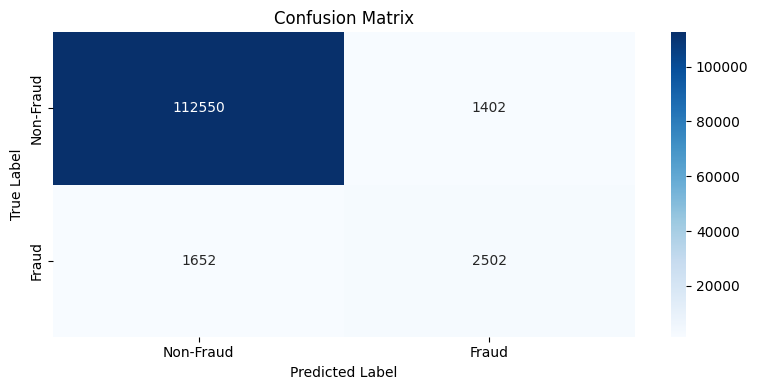

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion matrix values from your result
cm = confusion_matrix(y_test, y_pred)

# Labels for display
labels = ["Non-Fraud", "Fraud"]

# Plot the confusion matrix
plt.figure(figsize=(8, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [101]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC AUC Score: ", roc_auc_score(y_test, y_proba))


Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99    113952
           1       0.64      0.60      0.62      4154

    accuracy                           0.97    118106
   macro avg       0.81      0.80      0.80    118106
weighted avg       0.97      0.97      0.97    118106

ROC AUC Score:  0.9425622827684281


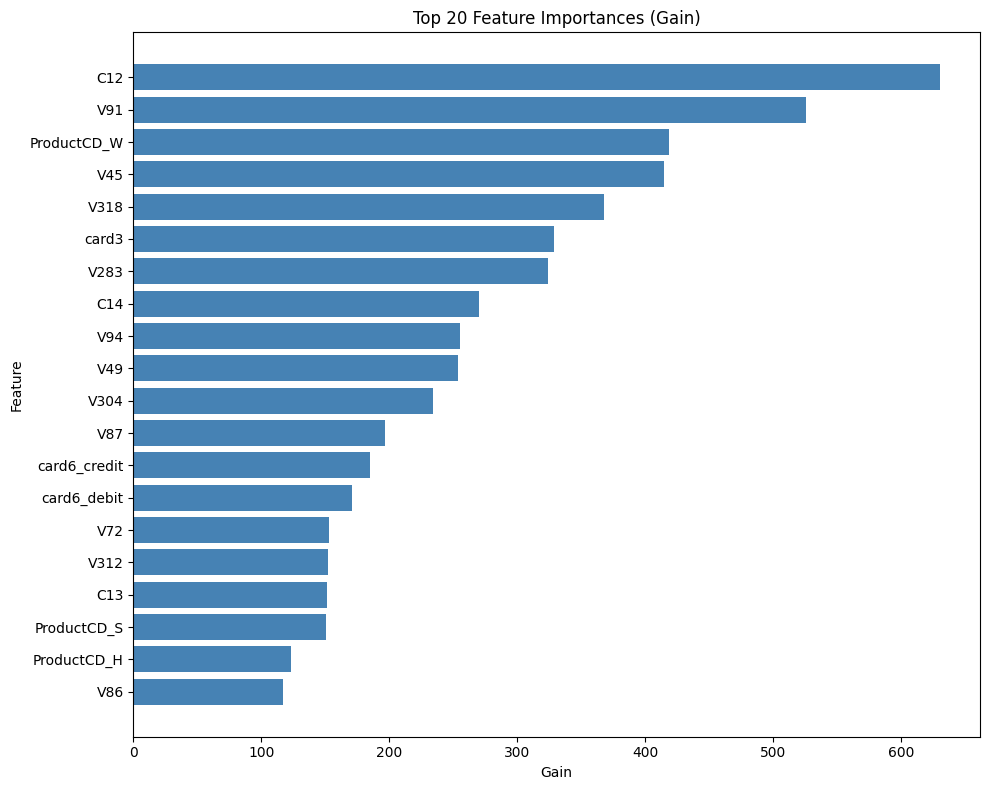

In [102]:
import matplotlib.pyplot as plt
import pandas as pd

xgb_model = pipeline.named_steps['classifier']

importance = xgb_model.get_booster().get_score(importance_type='gain')

importance_df = pd.DataFrame({
    'feature': list(importance.keys()),
    'importance': list(importance.values())
}).sort_values('importance', ascending=True).tail(20)

plt.figure(figsize=(10, 8))
plt.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
plt.xlabel('Gain')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importances (Gain)')
plt.tight_layout()
plt.show()

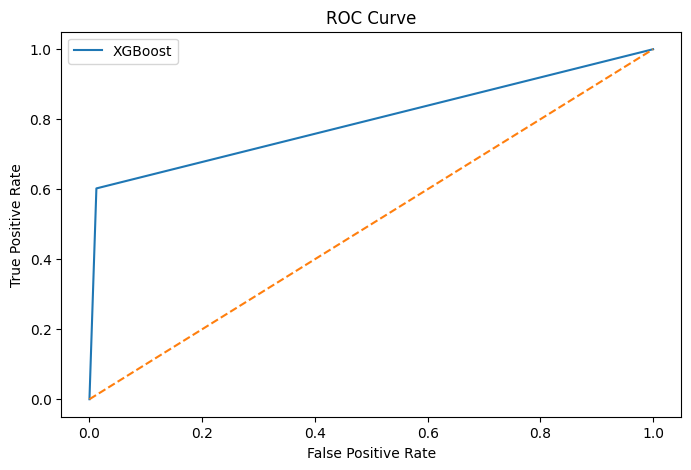

In [103]:
# Calculate ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred)

# Plot Figure
plt.figure(figsize=(8,5))

# Plot ROC Curve
plt.plot(fpr, tpr, label='XGBoost')

# Diagonal Line
plt.plot([0,1], [0,1], linestyle='--')

# Labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')

# Legend
plt.legend()

# Show Plot
plt.show()

### LightGbm Implementation '

In [106]:
! pip install lightgbm


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
